<a href="https://colab.research.google.com/github/emmatorres-bsm/telefonica/blob/main/Versi%C3%B3n_2_TELEFONICA_RETO_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

La primera fase del proyecto evidenció un problema crítico. Aunque logramos construir un detector de fraude con una sensibilidad casi perfecta (identificando el 99.78% de los ataques spoof), el análisis de la matriz de confusión destapó la realidad: el modelo aseguraba su éxito a costa de bloquear por error al 85% de los clientes humanos legítimos (falsos positivos).

Un sistema con esta tasa de falsas alarmas, por muy seguro que sea, es comercialmente inviable porque destruiría por completo el servicio y la atención al cliente.

Por ello, esta segunda versión plantea un nuevo reto: ¿Podemos reequilibrar la balanza? El objetivo ahora es aplicar técnicas más avanzadas que enseñen al modelo a distinguir realmente la voz humana, manteniendo una barrera sólida contra el fraude sin sacrificar a los usuarios legítimos.

### **1. CONSTRUCCIÓN DEL NUEVO DATASET BALANCEADO**

Se conservan todos los audios bonafide disponibles.

Posteriormente, seleccionamos el mismo número total de audios spoof distribuidos equitativamente entre todas las familias de ataque.

Esta estrategia busca:

- reducir el sesgo hacia la clase spoof
- mejorar la representación de voces humanas
- favorecer la generalización

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np

ruta_train = '/content/drive/MyDrive/telefonica/train_features_mfcc.csv'
df_train_final = pd.read_csv(ruta_train)

df_bonafide = df_train_final[df_train_final['y1'] == 0]
df_spoof = df_train_final[df_train_final['y1'] == 1]

num_bonafide = len(df_bonafide)
print(f"Audios humanos (bonafide) disponibles: {num_bonafide}")

tipos_de_ataque = df_spoof['y2'].unique()
muestras_por_ataque = num_bonafide // len(tipos_de_ataque)
print(f"Seleccionando {muestras_por_ataque} muestras de cada uno de los {len(tipos_de_ataque)} tipos de ataque para igualar.")

df_spoof_balanceado = df_spoof.groupby('y2').apply(
    lambda x: x.sample(n=min(len(x), muestras_por_ataque), random_state=42)
).reset_index(drop=True)

df_train_balanced = pd.concat([df_bonafide, df_spoof_balanceado]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nNUEVO DATASET BALANCEADO: Humanos: {len(df_train_balanced[df_train_balanced['y1']==0])} | Fraudes: {len(df_train_balanced[df_train_balanced['y1']==1])}")

ruta_guardado = '/content/drive/MyDrive/telefonica/train_balanced_mfcc.csv'
df_train_balanced.to_csv(ruta_guardado, index=False)
print(f"Dataset balanceado guardado en: {ruta_guardado}\n")

X_train_bal = df_train_balanced.drop(columns=['file_name', 'y1', 'y2'], errors='ignore')
y_train_bal = df_train_balanced['y1']

print("Matrices X_train_bal y y_train_bal listas para entrenar.")

Audios humanos (bonafide) disponibles: 2580
Seleccionando 430 muestras de cada uno de los 6 tipos de ataque para igualar.

NUEVO DATASET BALANCEADO: Humanos: 2580 | Fraudes: 2580
Dataset balanceado guardado en: /content/drive/MyDrive/telefonica/train_balanced_mfcc.csv

Matrices X_train_bal y y_train_bal listas para entrenar.


A diferencia de la V1, donde el modelo aprendía sobre una distribución dominada por ejemplos spoof, esta nueva configuración garantiza una representación equilibrada entre voces humanas y sintéticas.

Nuestra hipótesis es que este cambio permitirá mejorar el reconocimiento de usuarios legítimos sin modificar las características acústicas utilizadas.

Dado que el EDA tiene como objetivo comprender la distribución real del problema, este análisis ya se realizó de forma exhaustiva sobre las particiones originales en la primera fase. Realizar un EDA sobre el nuevo dataset carecería de sentido metodológico, ya que su distribución ha sido alterada artificialmente (balanceada) para el entrenamiento, por lo que procedemos directamente a entrenar y evaluar los modelos.

### **2. SELECCIÓN DE MÉTRICAS: BALANCED ACCURACY**
Por recomendación académica y con el objetivo de evitar los "espejismos" estadísticos de la fase anterior, en esta versión priorizaremos la Balanced Accuracy sobre la precisión global. Mientras que la precisión estándar puede verse inflada por la clase con mayor número de muestras, la Balanced Accuracy calcula la media aritmética del recall de cada clase (humano y fraude).

Esto nos permite obtener una visión justa y equitativa del rendimiento del modelo, garantizando que el éxito en la detección de ataques no se consiga a costa de ignorar a los usuarios legítimos.

### **3. ENTRENAMIENTO Y COMPARACIÓN DE MODELOS**

Se repite el proceso completo de experimentación utilizando las mismas familias de modelos evaluadas en la primera versión.

De esta manera, cualquier mejora observada podrá atribuirse al balanceo del dataset y no al cambio de algoritmo.

***3.1. Regresión logística***


Comenzamos nuestra experimentación sobre el dataset balanceado estableciendo una Regresión Logística como nuestro modelo base. Para asegurar un rendimiento óptimo, incorporamos un StandardScaler mediante un pipeline. Esto garantiza que todos los coeficientes de los MFCCs se calculen sobre una magnitud uniforme y evita data leakage durante la validación cruzada.

Evaluamos dos configuraciones ajustando el hiperparámetro de regularización (C) mediante Stratified 5-Fold Cross-Validation:

Versión estándar (C=1.0): Permite al modelo ajustarse a los patrones de los datos con una penalización equilibrada.

Versión regularizada (C=0.01): Aplica una penalización fuerte sobre los pesos del modelo para simplificar la frontera de decisión y mejorar la generalización.


In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import warnings
warnings.filterwarnings('ignore')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("MODELO 1: REGRESIÓN LOGÍSTICA (Con escalado)")

pipeline_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

scores_1 = cross_validate(pipeline_1, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración C=1.0 (Regularización Estándar)")
print(f"Balanced Accuracy: {np.mean(scores_1['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_1['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_1['test_f1']):.4f}")


pipeline_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(C=0.01, max_iter=1000, random_state=42))
])

scores_2 = cross_validate(pipeline_2, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración C=0.01 (Alta regularización)")
print(f"Balanced Accuracy: {np.mean(scores_2['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_2['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_2['test_f1']):.4f}")
print("-" * 40)

MODELO 1: REGRESIÓN LOGÍSTICA (Con escalado)
----------------------------------------
Configuración C=1.0 (Regularización Estándar)
Balanced Accuracy: 0.8436
Recall fraude:     0.8298
F1-Score:          0.8414
----------------------------------------
Configuración C=0.01 (Alta regularización)
Balanced Accuracy: 0.8353
Recall fraude:     0.8027
F1-Score:          0.8297
----------------------------------------


Los resultados confirman que el balanceo del dataset ha eliminado el espejismo de la primera fase. Alcanzar casi un 84% de Balanced Accuracy demuestra que el modelo por fin está aprendiendo a distinguir los matices entre voces humanas y sintéticas, en lugar de limitarse a predecir siempre fraude. Como contrapartida esperada, el Recall de ataques baja al 83%; un sacrificio necesario para dejar de bloquear por error masivamente a los clientes legítimos. Entre las configuraciones probadas, la versión estándar (C=1.0) resulta ser la óptima, ya que aplicar un exceso de regularización (C=0.01) asfixia al algoritmo y empeora su capacidad de detección general.

***3.2. Random Forest***

A diferencia de la regresión logística, Random Forest es un algoritmo de ensamble no lineal. Al combinar las decisiones de múltiples árboles, es capaz de trazar fronteras de decisión mucho más complejas y adaptarse a los intrincados patrones de los coeficientes MFCC.

Evaluamos dos configuraciones ajustando el número de árboles (n_estimators), manteniendo la validación cruzada estratificada (K=5) sobre el dataset balanceado:

Versión de 50 árboles: Equilibrio entre precisión y coste computacional.

Versión de 100 árboles: Mayor complejidad para intentar capturar características más sutiles de la voz.

In [20]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

print("MODELO 2: RANDOM FOREST")


rf_50 = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
scores_rf50 = cross_validate(rf_50, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración 1: Random Forest (50 árboles)")
print(f"Balanced Accuracy: {np.mean(scores_rf50['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_rf50['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_rf50['test_f1']):.4f}")


rf_100 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scores_rf100 = cross_validate(rf_100, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración 2: Random Forest (100 árboles)")
print(f"Balanced Accuracy: {np.mean(scores_rf100['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_rf100['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_rf100['test_f1']):.4f}")
print("-" * 40)


MODELO 2: RANDOM FOREST
----------------------------------------
Configuración 1: Random Forest (50 árboles)
Balanced Accuracy: 0.9246
Recall fraude:     0.9066
F1-Score:          0.9232
----------------------------------------
Configuración 2: Random Forest (100 árboles)
Balanced Accuracy: 0.9258
Recall fraude:     0.9097
F1-Score:          0.9245
----------------------------------------


Al entrenar con el dataset balanceado, hemos dejado atrás ese 99% de Recall de la primera fase, estabilizándonos ahora en un robusto 91%. Esto demuestra que el algoritmo ya no hace "trampas" prediciendo sistemáticamente todo como ataque, sino que por fin está aprendiendo a separar las fronteras reales entre voz natural y sintética. Alcanzar más de un 92.5% de Balanced Accuracy confirma que ahora somos capaces de cazar el fraude con gran eficacia, pero protegiendo al mismo tiempo a los clientes legítimos. Ambas configuraciones rinden de forma muy similar, aunque la versión de 100 árboles aporta una ligera mejora de estabilidad que la convierte en nuestro mejor candidato.

***3.3. Support Vector Machines***

Este algoritmo dibuja un "pasillo" o margen de seguridad máximo entre las clases. Dado que el SVM se basa puramente en calcular distancias geométricas para crear este pasillo, es un modelo extremadamente sensible a la escala de los datos. Por ello, es obligatorio aplicar primero un StandardScaler integrado en un Pipeline, asegurando así que todas las variables tengan el mismo peso y evitando fugas de información durante la validación cruzada.

Con los datos correctamente escalados, vamos a probar el hiperparámetro kernel, que cambia la forma en la que el algoritmo ve el espacio de datos y traza la frontera:

Versión 1 (kernel='linear'): intentará separarlos con una barrera recta. Su rendimiento debería ser muy parecido al de la regresión logística.

Versión 2 (kernel='rbf'): usa una función matemática que proyecta los datos a un espacio tridimensional o superior, permitiendo dibujar fronteras curvas y complejas.

In [21]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

print("MODELO 3: SVM")


svm_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=42, max_iter=2000))
])
scores_lin = cross_validate(svm_linear, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración 1: SVM (Kernel Lineal)")
print(f"Balanced Accuracy: {np.mean(scores_lin['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_lin['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_lin['test_f1']):.4f}")


svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42, max_iter=2000))
])
scores_rbf = cross_validate(svm_rbf, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración 2: SVM (Kernel RBF)")
print(f"Balanced Accuracy: {np.mean(scores_rbf['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_rbf['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_rbf['test_f1']):.4f}")
print("-" * 40)

MODELO 3: SVM
----------------------------------------
Configuración 1: SVM (Kernel Lineal)
Balanced Accuracy: 0.7320
Recall fraude:     0.7202
F1-Score:          0.7288
----------------------------------------
Configuración 2: SVM (Kernel RBF)
Balanced Accuracy: 0.9605
Recall fraude:     0.9469
F1-Score:          0.9599
----------------------------------------


Los resultados confirman el planteamiento teórico. El kernel lineal (73% de Balanced Accuracy) resulta insuficiente, demostrando que las voces reales y sintéticas no pueden separarse eficazmente mediante una simple frontera recta. Por el contrario, el kernel RBF, al utilizar fronteras no lineales y proyectar los datos a dimensiones superiores, alcanza un sobresaliente 96.05% de Balanced Accuracy. Con casi un 95% en la detección de fraude, esta configuración logra un gran equilibrio entre la estricta seguridad del sistema y la protección del usuario legítimo, posicionándose como un candidato sumamente fuerte a la espera de evaluar nuestro último algoritmo.

***3.4. XGBOOST***

Para cerrar nuestra fase de experimentación, implementamos XGBoost, un algoritmo de gradient boosting que construye árboles de forma secuencial para corregir errores previos. Evaluaremos primero una configuración con 50 estimadores y, posteriormente, una versión con 100 estimadores y una profundidad máxima de 4, buscando determinar si este modelo logra optimizar aún más los resultados obtenidos por el SVM.

In [22]:
from xgboost import XGBClassifier
import numpy as np

print("MODELO 4: XGBOOST")

# 1. Configuración 50 estimadores
xgb_50 = XGBClassifier(n_estimators=50, learning_rate=0.1, random_state=42, n_jobs=-1)
scores_xgb50 = cross_validate(xgb_50, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración 1: XGBoost (50 estimadores)")
print(f"Balanced Accuracy: {np.mean(scores_xgb50['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_xgb50['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_xgb50['test_f1']):.4f}")


xgb_100 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, n_jobs=-1)
scores_xgb100 = cross_validate(xgb_100, X_train_bal, y_train_bal, cv=skf, scoring=['balanced_accuracy','recall', 'f1'], n_jobs=-1)

print("-" * 40)
print("Configuración 2: XGBoost (100 est., prof. 4)")
print(f"Balanced Accuracy: {np.mean(scores_xgb100['test_balanced_accuracy']):.4f}")
print(f"Recall fraude:     {np.mean(scores_xgb100['test_recall']):.4f}")
print(f"F1-Score:          {np.mean(scores_xgb100['test_f1']):.4f}")
print("-" * 40)

MODELO 4: XGBOOST
----------------------------------------
Configuración 1: XGBoost (50 estimadores)
Balanced Accuracy: 0.9147
Recall fraude:     0.8907
F1-Score:          0.9126
----------------------------------------
Configuración 2: XGBoost (100 est., prof. 4)
Balanced Accuracy: 0.9167
Recall fraude:     0.8926
F1-Score:          0.9146
----------------------------------------


El XGBoost demuestra ser un algoritmo robusto, superando el 91.6% de Balanced Accuracy con su segunda configuración. Sin embargo, en esta ocasión no logra batir la sobresaliente marca del 96% establecida por el SVM con kernel RBF, quedándose incluso ligeramente por debajo del rendimiento del Random Forest. Con estos resultados, el SVM se confirma definitivamente como el modelo ganador de esta fase de entrenamiento y nuestra mejor opción para pasar a la evaluación final.

### **4. SELECCIÓN DEL NUEVO MODELO**

El SVM con kernel RBF se consolida como el ganador indiscutible al liderar de forma contundente en todas las métricas clave, destacando su 96.05% de Balanced Accuracy. No solo es el modelo que mejor equilibra la balanza protegiendo la experiencia del usuario legítimo, sino que también ofrece la mayor seguridad al registrar un 94.69% de Recall frente al fraude, superando holgadamente a Random Forest y XGBoost. Estos resultados demuestran que la proyección a un espacio no lineal es la única estrategia capaz de capturar con precisión los complejos matices de los audios.

Tras comparar todos los candidatos mediante validación cruzada, el modelo seleccionado como campeón es SVM con kernel RBF.

Este modelo obtiene la mejor balanced accuracy global, mostrando el mejor equilibrio entre:

- detección de fraude
- reconocimiento de usuarios humanos legítimos

Por este motivo, será el candidato utilizado para la evaluación final sobre test.

### **5. EVALUACIÓN FINAL SOBRE TEST**

Datos de Test cargados: 24844 muestras.

Entrenando al modelo ganador para el examen final

   REPORTE DE CLASIFICACIÓN FINAL (TEST)
              precision    recall  f1-score   support

      Humano       0.42      0.65      0.51      2548
      Fraude       0.96      0.90      0.93     22296

    accuracy                           0.87     24844
   macro avg       0.69      0.77      0.72     24844
weighted avg       0.90      0.87      0.88     24844

Balanced Accuracy final: 0.7723


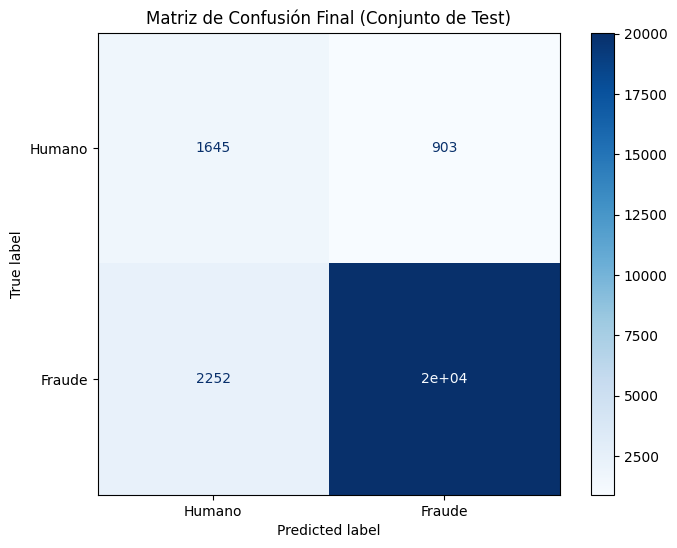

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

ruta_test = '/content/drive/MyDrive/telefonica/test_features_mfcc.csv'
df_test = pd.read_csv(ruta_test)

X_test = df_test.drop(columns=['file_name', 'y1', 'y2'], errors='ignore')
y_test = df_test['y1']

print(f"Datos de Test cargados: {len(X_test)} muestras.\n")

campeon = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42, probability=True))
])

print("Entrenando al modelo ganador para el examen final")
campeon.fit(X_train_bal, y_train_bal)

y_pred = campeon.predict(X_test)

print("\n" + "="*40)
print("   REPORTE DE CLASIFICACIÓN FINAL (TEST)")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['Humano', 'Fraude']))


balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)

print(f"Balanced Accuracy final: {balanced_acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Humano', 'Fraude'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión Final (Conjunto de Test)')
plt.show()

Los resultados confirman que el modelo mantiene una elevada capacidad de detección de fraude.

Al mismo tiempo, se observa una mejora muy significativa en el recall de usuarios humanos respecto a la primera versión.


### **6. CONCLUSIONES FINALES**

El análisis de este reporte final sobre el conjunto de test demuestra que la estrategia de balanceo ha funcionado y nos ha sacado del atasco, pero también deja claro que todavía tenemos margen de mejora. El objetivo primordial de esta Fase 2 era mitigar la extrema rigidez del primer modelo, el cual generaba un volumen inasumible de falsos positivos al bloquear sistemáticamente a los usuarios legítimos. Con el nuevo enfoque, el recall para la clase humana ha aumentado drásticamente hasta alcanzar el 65%, lo que significa que casi dos tercios de los clientes reales logran superar el filtro de seguridad de Telefónica sin sufrir bloqueos injustificados. Lo más satisfactorio es que este incremento en la usabilidad no ha desmantelado la seguridad del sistema, ya que el modelo mantiene un sólido 90% de recall en la detección de fraude, logrando identificar de forma efectiva a 9 de cada 10 ataques de voz sintética. Al promediar ambos aciertos, obtenemos una Balanced Accuracy intermedia del 77.5%, que refleja cómo se comporta este SVM en el entorno real desbalanceado.

Es importante destacar que el valor del 42% en la precisión de la clase humana tiene una explicación puramente matemática ligada a la naturaleza desbalanceada del entorno de evaluación. En este conjunto de datos, la presencia de fraude es masiva, con más de 22,000 muestras frente a apenas 2,548 audios humanos. Debido a esta enorme disparidad, el pequeño 10% de fraudes que consiguen eludir al modelo representa en volumen absoluto a unas 2,230 llamadas falsas que se clasifican erróneamente como legítimas. Al mezclarse con el grupo de humanos reales, este residuo matemático deforma y deprime la métrica de precisión, una distorsión clásica que justifica por qué estamos usando la Balanced Accuracy para guiar el rumbo del proyecto.

En conclusión, este experimento demuestra que el laboratorio de entrenamiento al 50/50 ha cumplido su propósito de rescatar la experiencia de los clientes reales al abrirles paso en la plataforma de forma mucho más fluida. Sin embargo, dejar a un 35% de usuarios legítimos atrapados en el filtro sigue siendo un precio alto para el negocio. Estos resultados validan por completo la necesidad de avanzar hacia la Fase 3, donde buscaremos técnicas de optimización más avanzadas para empujar ese 65% de recall humano hacia arriba sin abrirle las puertas al fraude.